Libraires

In [42]:
import os
import numpy as np
import matplotlib.pyplot as plt
import operator
import torch
import torch.nn as nn

Paramètres

In [53]:
FEATURES_DIR = 'VGG16' 
ORIGINAL_IMAGES_DIR = 'MIR_DATASETS_B' 
QUERY_IMAGE_KEY = '4_5_singes_baboon_4496'
NUM_NEIGHBORS_TO_DISPLAY = 20
IMAGE_DISPLAY_SIZE = 2

In [ ]:
def euclidean_distance(vec1, vec2):
    return np.sqrt(np.sum((vec1 - vec2) ** 2))

def load_all_features_from_dir(features_directory):
    features_dict = {}
    if not os.path.exists(features_directory):
        print(f"Erreur : Le dossier '{features_directory}' est introuvable. Veuillez le créer et y placer vos fichiers de features.")
        return features_dict

    print(f"Chargement des features depuis le dossier : {features_directory}")
    for filename in os.listdir(features_directory):
        if filename.endswith('.txt'):
            base_name = os.path.splitext(filename)[0] # Nom sans extension
            full_filepath = os.path.join(features_directory, filename)
            try:
                feature = np.loadtxt(full_filepath)
                features_dict[base_name] = feature
            except Exception as e:
                print(f"Erreur lors du chargement de {filename}: {e}")
    print(f"Nombre total de features chargées : {len(features_dict)}")
    return features_dict

def getkVoisins(features_dict, query_key, k):
    actual_query_key = os.path.splitext(query_key)[0] 

    if actual_query_key not in features_dict:
        raise ValueError(f"L'image requête '{query_key}' (normalisée en '{actual_query_key}') n'existe pas dans les features ! "
                         f"Vérifiez que '{actual_query_key}' est une clé valide dans votre dictionnaire de features. "
                         f"Exemples de clés dans le dictionnaire: {list(features_dict.keys())[:min(10, len(features_dict))]}")

    query_feature = features_dict[actual_query_key]
    distances = []


    distances.append((actual_query_key, 0.0))

    for img_key, feature in features_dict.items():
        if img_key != actual_query_key: # Ne pas comparer l'image avec elle-même à nouveau
            dist = euclidean_distance(query_feature, feature)
            distances.append((img_key, dist))

    distances.sort(key=operator.itemgetter(1))
    return distances[:k]

def get_image_path_from_key(image_key, base_images_dir):
    possible_extensions = ['.jpg', '.jpeg', '.png', '.bmp']
    
    # Tentative 1: Structure hiérarchique (category/subcategory/image.jpg)
    parts = image_key.split('_')
    if len(parts) >= 4:
        try:
            category = parts[2] 
            subcategory = parts[3] 
            potential_hierarchical_path_base = os.path.join(base_images_dir, category, subcategory, image_key)
            for ext in possible_extensions:
                img_path = potential_hierarchical_path_base + ext
                if os.path.exists(img_path):
                    return img_path
        except IndexError: # Au cas où split('_') ne donne pas assez de parties
            pass # Continuer à essayer les autres options

    # Tentative 2: Structure plate (image_name.jpg directement dans base_images_dir)
    potential_flat_path_base = os.path.join(base_images_dir, image_key)
    for ext in possible_extensions:
        img_path = potential_flat_path_base + ext
        if os.path.exists(img_path):
            return img_path

    return None # Image non trouvée après toutes les tentatives

Fonctions pour afficher les plus proches, calculer la sous catégorie et afficher la courbe de Recall-Precision

In [ ]:
def display_images(image_keys_and_distances, base_images_dir, query_key):
    """
    Affiche une grille d'images avec leurs distances.
    """
    if not image_keys_and_distances:
        print("Aucune image à afficher.")
        return

    num_images = len(image_keys_and_distances)
    num_cols = min(5, num_images) # Max 5 colonnes pour la lisibilité
    num_rows = (num_images + num_cols - 1) // num_cols

    fig, axes = plt.subplots(num_rows, num_cols, figsize=(num_cols * IMAGE_DISPLAY_SIZE, num_rows * IMAGE_DISPLAY_SIZE))
    axes = axes.flatten() # Pour itérer facilement même si c'est une seule ligne ou colonne

    for i, (image_key, distance) in enumerate(image_keys_and_distances):
        if i >= len(axes): # Éviter les erreurs si plus d'images que de subplots (ne devrait pas arriver)
            break

        ax = axes[i]
        img_path = get_image_path_from_key(image_key, base_images_dir)

        if img_path and os.path.exists(img_path):
            try:
                img = Image.open(img_path)
                ax.imshow(img)
                title = f"D: {distance:.2f}"
                if image_key == query_key:
                    title = "Query (D: 0.00)"
                ax.set_title(title, fontsize=8)
                ax.axis('off') # Cacher les axes
            except Exception as e:
                ax.set_title(f"Erreur ({image_key})", fontsize=8)
                ax.text(0.5, 0.5, "Image non \nchargeable", horizontalalignment='center', verticalalignment='center', transform=ax.transAxes, color='red')
                ax.axis('off')
                print(f"Impossible de charger l'image {img_path}: {e}")
        else:
            ax.set_title(f"Introuvable ({image_key})", fontsize=8)
            ax.text(0.5, 0.5, "Image non \ntrouvée", horizontalalignment='center', verticalalignment='center', transform=ax.transAxes, color='red')
            ax.axis('off')
            print(f"Chemin d'image introuvable pour la clé {image_key} : {img_path}")
            
    # Masquer les axes non utilisés
    for j in range(num_images, len(axes)):
        fig.delaxes(axes[j])

    plt.tight_layout()
    plt.suptitle(f"Top {num_images} plus proches voisins de '{query_key}'", y=1.02, fontsize=14)
    plt.show()

# --- Fonctions pour la courbe Rappel-Précision (R-P) ---
def get_category_from_filename(filename_key):
    # Retirer le suffixe '_visual' si présent (pour les features VGG16)
    if filename_key.endswith('_visual'):
        filename_key = filename_key[:-7] # Enlève '_visual'

    parts = filename_key.split('_')
    # Si le format est 'X_Y_category_subcategory_ID'
    if len(parts) >= 4:
        return parts[3] # 'subcategory' est la 4ème partie (index 3)
    return None # Si le format ne correspond pas

def calculate_precision_recall(features_dict, query_key, k_max):
    query_category = get_category_from_filename(query_key)
    if query_category is None:
        print(f"Impossible de déterminer la catégorie pour la clé de requête: {query_key}. Impossible de calculer R-P.")
        return [], []

    # Déterminer le nombre total d'éléments pertinents dans la base de données
    all_relevant_items_count = sum(1 for f_key in features_dict.keys() if get_category_from_filename(f_key) == query_category)
    if query_key in features_dict and get_category_from_filename(query_key) == query_category:
        all_relevant_items_count -= 1 

    if all_relevant_items_count <= 0: 
        print(f"Aucun élément pertinent trouvé pour la catégorie '{query_category}' (à part la requête elle-même) dans la base de données. R-P non applicable.")
        return [], []

    try:
        neighbors_with_query = getkVoisins(features_dict, query_key, k_max + 1) 
        neighbors = [(key, dist) for key, dist in neighbors_with_query if key != os.path.splitext(query_key)[0]]
        neighbors = neighbors[:k_max]

    except ValueError as e:
        print(f"Erreur lors de la récupération des voisins pour {query_key}: {e}")
        return [], []
    except Exception as e:
        print(f"Une erreur inattendue est survenue lors de getkVoisins: {e}")
        return [], []

    precision_values = []
    recall_values = []
    relevant_retrieved_count = 0

    for i, (retrieved_key, dist) in enumerate(neighbors):
        retrieved_category = get_category_from_filename(retrieved_key)
        
        if retrieved_category == query_category:
            relevant_retrieved_count += 1

        current_precision = relevant_retrieved_count / (i + 1)
        current_recall = relevant_retrieved_count / all_relevant_items_count

        precision_values.append(current_precision)
        recall_values.append(current_recall)

    return recall_values, precision_values

Chargement des features depuis le dossier : VGG16
Nombre total de features chargées : 4505

--- Affichage des 20 plus proches voisins ---


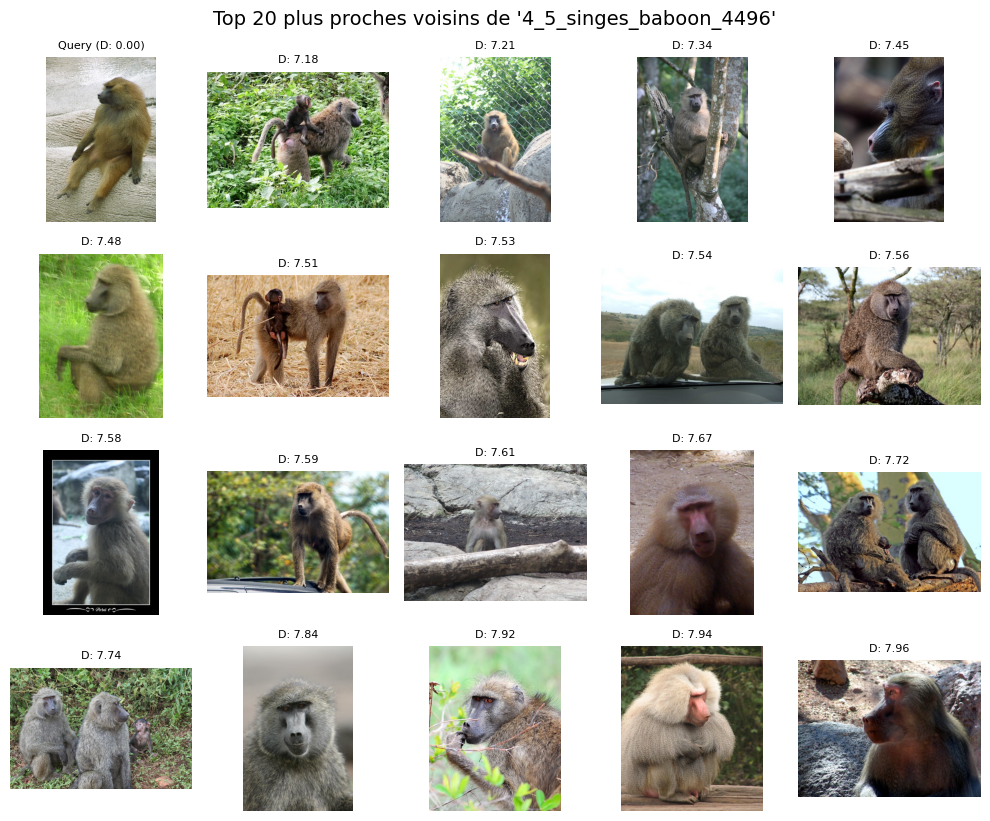


--- Calcul et affichage de la courbe Rappel-Précision (R-P) ---


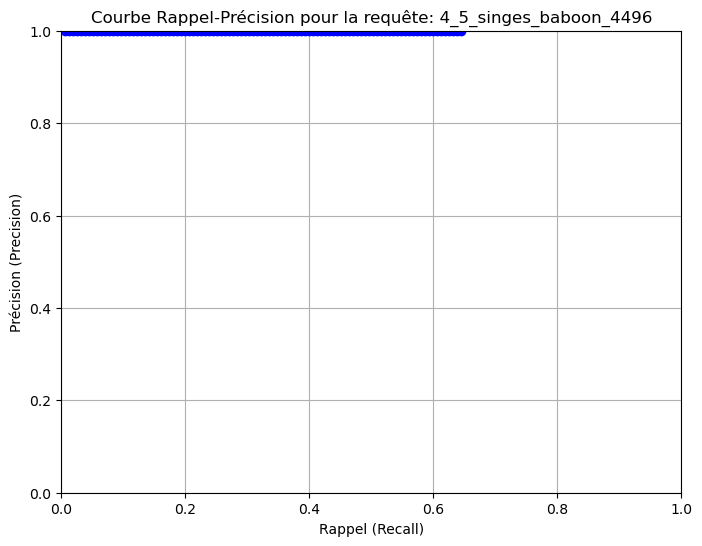

In [ ]:
if __name__ == "__main__":
    # 1. Charger les features
    features_data = load_all_features_from_dir(FEATURES_DIR)

    if not features_data:
        print("Aucune feature chargée. Arrêt du script.")
    else:
        # 2. Déterminer la clé de requête finale pour le traitement
        final_query_key = os.path.splitext(QUERY_IMAGE_KEY)[0] 

        if final_query_key not in features_data:
            if len(features_data) > 0:
                print(f"Avertissement : La clé de requête configurée '{QUERY_IMAGE_KEY}' (normalisée en '{final_query_key}') n'a pas été trouvée."
                      f"Utilisation de la première clé disponible pour le test : '{list(features_data.keys())[0]}'")
                final_query_key = list(features_data.keys())[0]
            else:
                print("Erreur : Le dictionnaire de features est vide. Impossible de trouver des voisins.")
                final_query_key = None

        if final_query_key:
            print(f"\n--- Affichage des {NUM_NEIGHBORS_TO_DISPLAY} plus proches voisins ---")
            try:
                # Obtenir les voisins (inclut la requête)
                closest_neighbors_and_query = getkVoisins(features_data, final_query_key, NUM_NEIGHBORS_TO_DISPLAY)
                display_images(closest_neighbors_and_query, ORIGINAL_IMAGES_DIR, final_query_key)

            except ValueError as e:
                print(f"Erreur lors de la recherche et l'affichage des voisins : {e}")
            except Exception as e:
                print(f"Une erreur inattendue est survenue lors de l'affichage des voisins : {e}")

            # --- Calcul et affichage de la courbe Rappel-Précision (R-P) ---
            print(f"\n--- Calcul et affichage de la courbe Rappel-Précision (R-P) ---")
            k_rp_max = min(len(features_data) - 1, 100) # Maximum de 100 voisins pour R-P ou la taille du dataset -1
            if k_rp_max <= 0:
                print("Pas assez d'images pour calculer la courbe R-P.")
            else:
                recall, precision = calculate_precision_recall(features_data, final_query_key, k_rp_max)

                if recall and precision:
                    plt.figure(figsize=(8, 6))
                    plt.plot(recall, precision, marker='o', linestyle='-', color='b')
                    plt.xlabel('Rappel (Recall)')
                    plt.ylabel('Précision (Precision)')
                    plt.title(f'Courbe Rappel-Précision pour la requête: {final_query_key}')
                    plt.grid(True)
                    plt.xlim([0, 1])
                    plt.ylim([0, 1])
                    plt.show()
                else:
                    print("Impossible de générer la courbe R-P. Vérifiez les messages d'erreur précédents.")
        else:
            print("Aucune image de requête valide trouvée ou features_data vide. Arrêt du script.")